In [1]:
pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torchvision 
import torchvision.models.detection as models
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection import fasterrcnn_resnet50_fpn

In [37]:
import os 
import numpy as np
import pandas as pd 
import torchvision 
import ast
import re
import cv2 
from torchvision.ops import nms
from sklearn.metrics import auc
from PIL import Image, ImageDraw
from collections import Counter 
import matplotlib.pyplot as plt 
from tqdm import tqdm
from torchvision.ops import box_iou
from sklearn.metrics import precision_score, recall_score, f1_score
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T 
import torchvision.transforms as transforms
from torchvision.models.detection import FasterRCNN

In [14]:
# Hàm tạo mô hình Faster R-CNN
def get_model(num_classes):
    # Sử dụng Faster R-CNN với backbone ResNet50
    # model = models.fasterrcnn_resnet50_fpn(weights=models.FasterRCNN_ResNet50_FPN_Weights.COCO_V1)
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    
    # Thay đổi đầu ra (head) để phù hợp với số lớp của bạn
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
    
    return model

# Khởi tạo mô hình
num_classes = 7  
model = get_model(num_classes)

In [15]:
checkpoint = torch.load(r"model_new\fasterrcnn_resnet50_fpn_epoch_8.pth",map_location=torch.device('cpu'))

C:\Users\HoangVan\AppData\Local\Temp\ipykernel_14492\3861564238.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(r"model_new\fasterrcnn_resnet50_f

In [16]:
model.load_state_dict(checkpoint['model_state_dict'])

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [23]:
label_mapping = {
    'DNoHelmet': 1,
    'DHelmet': 2,
    'DHelmetPHelmet': 3,
    'DHelmetPNoHelmet': 4,
    'DNoHelmetPHelmet': 5,
    'DNoHelmetPNoHelmet': 6
}

In [24]:
label_mapping_2 = {
    1: 'DNoHelmet',
    2: 'DHelmet',
    3: 'DHelmetPHelmet',
    4: 'DHelmetPNoHelmet',
    5: 'DNoHelmetPHelmet',
    6: 'DNoHelmetPNoHelmet'
}

In [17]:
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

### Dự đoán ảnh

In [18]:
transform = T.Compose([
    T.Resize((512, 512)),  
    T.ToTensor()       
])


In [48]:
image_path = r"images\Yangon_II_30_63.jpg"
image = Image.open(image_path).convert("RGB")
image_tensor = transform(image).unsqueeze(0) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_tensor = image_tensor.to(device)

with torch.no_grad(): 
    predictions = model(image_tensor)
predictions 

[{'boxes': tensor([[276.0518, 311.7340, 322.0748, 428.7300],
          [369.0938, 305.0903, 431.5351, 472.0070],
          [179.4902, 302.5954, 197.5455, 354.3436],
          [246.2221, 301.2675, 264.0856, 350.3630],
          [206.6392, 301.5811, 228.6960, 342.6501],
          [174.4852, 299.9032, 191.8159, 349.1458],
          [366.9456, 299.0908, 404.2772, 353.1296],
          [367.4917, 297.6804, 406.0535, 352.8865],
          [178.4773, 303.0957, 197.8484, 354.9013],
          [368.6309, 303.7692, 414.2221, 395.4417],
          [245.9469, 300.6089, 263.8826, 350.7180],
          [219.4777, 302.2177, 236.8694, 342.0971],
          [246.0160, 300.6429, 264.6235, 350.9377]]),
  'labels': tensor([6, 6, 1, 1, 1, 1, 1, 6, 6, 6, 2, 1, 6]),
  'scores': tensor([0.9987, 0.9980, 0.9847, 0.9272, 0.1793, 0.1494, 0.1464, 0.1275, 0.1028,
          0.0705, 0.0662, 0.0560, 0.0556])}]

In [49]:
predicted_boxes = predictions[0]['boxes'].cpu().numpy()
predicted_labels = predictions[0]['labels'].cpu().numpy()
predicted_scores = predictions[0]['scores'].cpu().numpy()

threshold = 0.3
filtered_indices = predicted_scores > threshold

filtered_boxes = predicted_boxes[filtered_indices]
filtered_labels = predicted_labels[filtered_indices]
filtered_scores = predicted_scores[filtered_indices]

for i in range(len(filtered_boxes)):
    print(f"Box: {filtered_boxes[i]}, Label: {filtered_labels[i]}, Score: {filtered_scores[i]}")

Box: [276.05185 311.73404 322.07483 428.73004], Label: 6, Score: 0.9987338185310364
Box: [369.0938  305.09027 431.53506 472.00705], Label: 6, Score: 0.9980233907699585
Box: [179.49016 302.5954  197.54555 354.3436 ], Label: 1, Score: 0.9846943020820618
Box: [246.22214 301.26752 264.08557 350.36304], Label: 1, Score: 0.9271858334541321


In [50]:
predicted_boxes = predictions[0]['boxes'].cpu()
predicted_labels = predictions[0]['labels'].cpu()
predicted_scores = predictions[0]['scores'].cpu()

filtered_boxes = predicted_boxes[filtered_indices]
filtered_labels = predicted_labels[filtered_indices]
filtered_scores = predicted_scores[filtered_indices]

# Áp dụng NMS
iou_threshold = 0.4  # Ngưỡng IoU để loại bỏ các box dư thừa
nms_indices = nms(filtered_boxes, filtered_scores, iou_threshold)

# Lấy các box, label, score sau khi áp dụng NMS
filtered_boxes = filtered_boxes[nms_indices]
filtered_labels = filtered_labels[nms_indices]
filtered_scores = filtered_scores[nms_indices]

# In kết quả sau khi áp dụng NMS
for i in range(len(filtered_boxes)):
    print(f"Box: {filtered_boxes[i].numpy()}, Label: {filtered_labels[i].item()}, Score: {filtered_scores[i].item()}")
    
filtered_labels = filtered_labels.numpy()

Box: [276.05185 311.73404 322.07483 428.73004], Label: 6, Score: 0.9987338185310364
Box: [369.0938  305.09027 431.53506 472.00705], Label: 6, Score: 0.9980233907699585
Box: [179.49016 302.5954  197.54555 354.3436 ], Label: 1, Score: 0.9846943020820618
Box: [246.22214 301.26752 264.08557 350.36304], Label: 1, Score: 0.9271858334541321


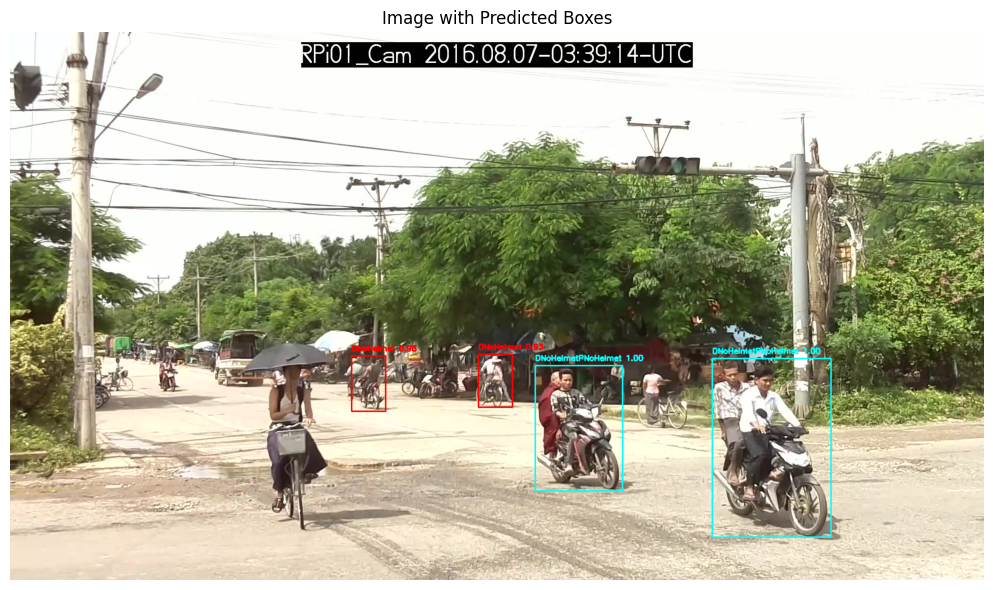

In [55]:
img_PIL = Image.open(image_path)
image_cv = img_PIL.convert("RGB")
image_cv = np.array(image_cv)

original_height, original_width = image_cv.shape[:2]
resized_image = cv2.resize(image_cv, (512, 512))

scale_x = original_width / 512
scale_y = original_height / 512

# Điều chỉnh bounding boxes về kích thước ban đầu
adjusted_image = image_cv.copy()
colors = [
    (255, 0, 0),    # Màu đỏ
    (0, 255, 0),    # Màu xanh lá
    (0, 0, 255),    # Màu xanh dương
    (255, 255, 0),  # Màu vàng
    (255, 0, 255),  # Màu hồng
    (0, 255, 255),  # Màu lục lam
]
for box, label, score in zip(filtered_boxes, filtered_labels, filtered_scores):
    xmin, ymin, xmax, ymax = box
    
    xmin_orig = int(xmin * scale_x)
    ymin_orig = int(ymin * scale_y)
    xmax_orig = int(xmax * scale_x)
    ymax_orig = int(ymax * scale_y)
    label_text = label_mapping_2[label]
    combine_text = f'{label_text} {score:0.2f}'
    color = colors[(int(label) - 1) % len(colors)]
    cv2.rectangle(adjusted_image, 
                  (xmin_orig, ymin_orig), 
                  (xmax_orig, ymax_orig), 
                  color, 2)
    
    cv2.putText(adjusted_image, combine_text, 
                (xmin_orig, ymin_orig - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 
                0.5, color, 2)  
   

plt.figure(figsize = (12,6))

plt.imshow(adjusted_image)
plt.axis("off")
plt.title("Image with Predicted Boxes")

plt.tight_layout()
plt.show()